In [161]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
df = pd.read_csv("02-seismic_activity_svm.csv")
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [163]:
df.info() # her column için 400 tane non-null değerimiz var boş data yok

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [164]:
df["seismic_event_detected"].unique()
# yine az önceki datasetteki gibi 0 ve 1 olarak classification yapacağız.

array([0, 1])

### Dataset'imizi önce Linear olarak çözümleyip daha sonra non-linear çözüme çevireceğiz.

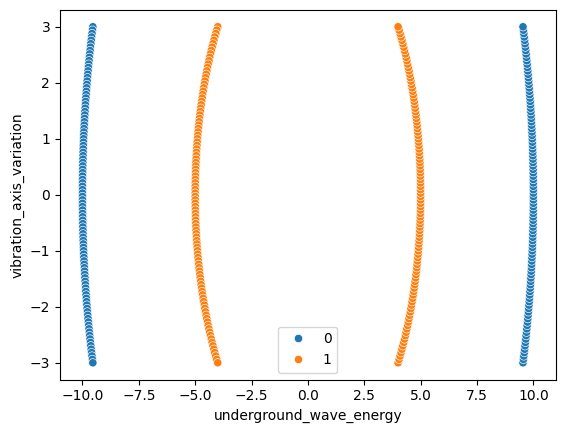

In [165]:
sns.scatterplot(x=df["underground_wave_energy"],y=df["vibration_axis_variation"],hue=df["seismic_event_detected"])
plt.legend()
plt.show()

In [166]:
X = df[["underground_wave_energy","vibration_axis_variation"]].values
y = df["seismic_event_detected"].values

In [167]:
X

array([[ 9.53939201, -3.        ],
       [ 9.55824059, -2.93939394],
       [ 9.57666854, -2.87878788],
       [ 9.59467828, -2.81818182],
       [ 9.61227215, -2.75757576],
       [ 9.62945245, -2.6969697 ],
       [ 9.64622137, -2.63636364],
       [ 9.66258107, -2.57575758],
       [ 9.67853361, -2.51515152],
       [ 9.69408101, -2.45454545],
       [ 9.70922521, -2.39393939],
       [ 9.7239681 , -2.33333333],
       [ 9.73831149, -2.27272727],
       [ 9.75225716, -2.21212121],
       [ 9.76580681, -2.15151515],
       [ 9.77896207, -2.09090909],
       [ 9.79172455, -2.03030303],
       [ 9.80409577, -1.96969697],
       [ 9.81607722, -1.90909091],
       [ 9.82767031, -1.84848485],
       [ 9.83887643, -1.78787879],
       [ 9.8496969 , -1.72727273],
       [ 9.86013297, -1.66666667],
       [ 9.87018588, -1.60606061],
       [ 9.87985679, -1.54545455],
       [ 9.88914683, -1.48484848],
       [ 9.89805706, -1.42424242],
       [ 9.90658851, -1.36363636],
       [ 9.91474216,

In [168]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [169]:
print(f"X Shape:{X.shape}, X Dimension: {X.ndim}, y Shape: {y.shape}, y Dimension: {y.ndim}")
# Burada biri X 2 boyutlu y tek boyutlu muhtemelen dimension'da sıkıntı yaşayacağız o yüzden
# Fakat boyuttan önce bu array'leri tensor'e çevirmeliyim
print(type(X))

X Shape:(400, 2), X Dimension: 2, y Shape: (400,), y Dimension: 1
<class 'numpy.ndarray'>


In [170]:
X = torch.tensor(X,dtype=torch.float32)
y = torch.tensor(y,dtype=torch.float32)

In [171]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [172]:
len(X_train),len(X_test),len(y_train),len(y_test)

(320, 80, 320, 80)

In [173]:
"""X_train = torch.tensor(X_train,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test,dtype=torch.float32).unsqueeze(1)"""

'X_train = torch.tensor(X_train,dtype=torch.float32)\nX_test = torch.tensor(X_test,dtype=torch.float32)\ny_train = torch.tensor(y_train,dtype=torch.float32).unsqueeze(1)\ny_test = torch.tensor(y_test,dtype=torch.float32).unsqueeze(1)'

In [174]:
# Sanırım train-test split'inden sonra tensor'e çevirmek daha yaygın kullanılan yaklaşım 
# ama şu anda hata gözükmüyor ve devam edeceğim bu yaklaşımla
y_test = y_test.unsqueeze(1)
y_train = y_train.unsqueeze(1)
print(y_test.ndim,y_train.ndim)
# 2 boyuta cıkardık bunlarıda.

2 2


In [175]:
from torch import nn
class ClassificationModel(nn.Module):
    
    def __init__(self):
        super().__init__()
        # Burada 3 katmanlı yapı kurmak istedim 2 tane girdimiz var.
        self.layer_1 = nn.Linear(in_features=2,out_features=4) 
        self.layer_2 = nn.Linear(in_features=4,out_features=5)
        self.layer_3 = nn.Linear(in_features=5,out_features=1)
    
    # forward propagation işlemi
    def forward(self, x: torch.Tensor)-> torch.Tensor:
        return self.layer_3(self.layer_2(self.layer_1(x)))

In [176]:
# sınıftan bir instance oluşturalım
model_0 = ClassificationModel()
model_0

ClassificationModel(
  (layer_1): Linear(in_features=2, out_features=4, bias=True)
  (layer_2): Linear(in_features=4, out_features=5, bias=True)
  (layer_3): Linear(in_features=5, out_features=1, bias=True)
)

In [177]:
# loss function'u ve optimizer'ımızı oluştrualım
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),lr=0.001)

In [178]:
# Hatırlatıcı olması adına accuracy fonksiyonu yazalım (hazırda kullanabiliriz.)
print(torch.eq(torch.tensor([0,1,1]),torch.tensor([0,1,0]))) # hatırlatıcı deneme
def calculate_accuracy(y_test,y_pred):
    correct_count = torch.eq(y_test,y_pred).sum().item()
    accuracy = (correct_count / len(y_pred)) * 100

    return accuracy

tensor([ True,  True, False])


In [179]:
torch.manual_seed(42)
epochs = 400

for epoch in range(epochs):
    model_0.train()  # train mode:on

    y_logits = model_0(X_train) # BCEWithLogitsLoss kullandıgımız icin bunu vereceğiz parametre olarak
    y_preds = torch.round(torch.sigmoid(y_logits)) # Accuracy için de predictionları aldık

    train_loss = loss_fn(y_logits,y_train)

    accuracy = calculate_accuracy(y_test = y_train, y_pred= y_preds)

    # Back propagation
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # model değerlendirmesi
    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test)
        test_preds = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits,y_test)
        test_acc = calculate_accuracy(y_test = y_test, y_pred=test_preds)

        if epoch % 5 == 0: #her 5 epochta bir görelim
            print(f"Epoch:{epoch}, Train loss {train_loss}, Train accuracy {accuracy}, Test Loss {test_loss}, Test accuracy {test_acc}")
            

Epoch:0, Train loss 0.815123438835144, Train accuracy 53.125, Test Loss 0.9640237092971802, Test accuracy 42.5
Epoch:5, Train loss 0.7866619825363159, Train accuracy 53.125, Test Loss 0.9196168184280396, Test accuracy 45.0
Epoch:10, Train loss 0.7626470327377319, Train accuracy 53.43750000000001, Test Loss 0.8806483149528503, Test accuracy 45.0
Epoch:15, Train loss 0.7431381940841675, Train accuracy 53.43750000000001, Test Loss 0.8472196459770203, Test accuracy 43.75
Epoch:20, Train loss 0.727929413318634, Train accuracy 51.5625, Test Loss 0.819146990776062, Test accuracy 45.0
Epoch:25, Train loss 0.7165910601615906, Train accuracy 51.87500000000001, Test Loss 0.7960859537124634, Test accuracy 40.0
Epoch:30, Train loss 0.7085506319999695, Train accuracy 52.1875, Test Loss 0.7776094079017639, Test accuracy 41.25
Epoch:35, Train loss 0.7031644582748413, Train accuracy 52.81249999999999, Test Loss 0.7632047533988953, Test accuracy 38.75
Epoch:40, Train loss 0.6997777819633484, Train accur

In [180]:
import numpy as np
def plot_linear_decision_boundary(model, X, y):

    # layer_1: (5,2)
    # layer_2: (1,5)
    # toplam efektif ağırlık = layer_2.weight @ layer_1.weight = (1,2)
    W1 = model.layer_1.weight.detach().numpy()       # shape (5,2)
    b1 = model.layer_1.bias.detach().numpy()         # shape (5,)
    W2 = model.layer_2.weight.detach().numpy()       # shape (1,5)
    b2 = model.layer_2.bias.detach().numpy()[0]      # shape (1,)

    # efektif W ve b
    # W_eff = W2 * W1
    W_eff = W2 @ W1   # shape (1,2)
    w1, w2 = W_eff[0] # iki feature'ın ağırlığı

    # efektif b = W2 * b1 + b2
    b_eff = (W2 @ b1)[0] + b2

    # X aralığı
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # Doğru denkleminden x2 hesaplama
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # Noktalar
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40)
    plt.plot(xs, ys, "k-", linewidth=3)
    plt.xlabel("subject_formality_score")
    plt.ylabel("sender_relationship_score")
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

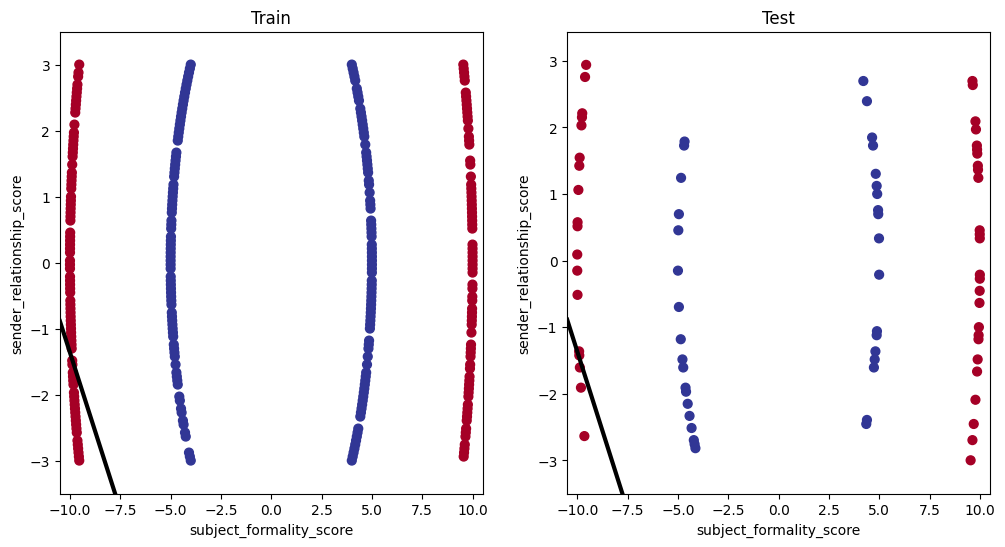

In [181]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_linear_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_linear_decision_boundary(model_0, X_test, y_test)
plt.show()
# Az önceki notebook'dan kodlar alındı sadece bu kısım için DEcision bonudary görmek adına
# Bu model maalesef linear olarak kötü çalışıyor non-linear ile eğitmeyi deneyelim

### Non-linear model

In [182]:
class NonLinearClassificationModel(nn.Module):

    def __init__(self):
        
        super().__init__()

        self.layer_1 = nn.Linear(in_features=2,out_features=4)
        self.layer_2 = nn.Linear(in_features=4,out_features=5)
        self.layer_3 = nn.Linear(in_features=5,out_features=1)

        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.layer_3(x)

        return x 

In [183]:
#instance yaratalım
model_1 = NonLinearClassificationModel()
model_1

NonLinearClassificationModel(
  (layer_1): Linear(in_features=2, out_features=4, bias=True)
  (layer_2): Linear(in_features=4, out_features=5, bias=True)
  (layer_3): Linear(in_features=5, out_features=1, bias=True)
  (relu): ReLU()
)

In [184]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),lr=0.001)

In [185]:
# loss_function'u ve optimizer'ı aynı kullanalım.
# eğitime geçelim
for epoch in range(epochs):

    model_1.train()

    y_logits_1 = model_1(X_train)
    y_preds_1 = torch.round(torch.sigmoid(y_logits_1))

    loss_1 = loss_fn(y_logits_1,y_train)
    accuracy_1 = calculate_accuracy(y_test=y_train,y_pred=y_preds_1)

    optimizer.zero_grad()
    loss_1.backward()
    optimizer.step()

    model_1.eval()
    with torch.inference_mode():
        test_logits_1 = model_1(X_test)
        test_preds_1 = torch.round(torch.sigmoid(test_logits_1))

        test_loss_1 = loss_fn(test_logits_1,y_test)
        test_accuracy_1 = calculate_accuracy(y_test=y_test,y_pred=test_preds_1)

        if epoch % 5 == 0:
            print(f"Epoch:{epoch}, Train loss {loss_1}, Train accuracy {accuracy_1}, Test loss {test_loss_1}, Test Accuracy {test_accuracy_1}")

Epoch:0, Train loss 0.7984287738800049, Train accuracy 51.24999999999999, Test loss 0.8778126835823059, Test Accuracy 45.0
Epoch:5, Train loss 0.7870856523513794, Train accuracy 51.24999999999999, Test loss 0.8618601560592651, Test Accuracy 45.0
Epoch:10, Train loss 0.7763630151748657, Train accuracy 51.24999999999999, Test loss 0.8466785550117493, Test Accuracy 45.0
Epoch:15, Train loss 0.7662802934646606, Train accuracy 51.24999999999999, Test loss 0.8323291540145874, Test Accuracy 45.0
Epoch:20, Train loss 0.7568519115447998, Train accuracy 51.24999999999999, Test loss 0.8188187479972839, Test Accuracy 45.0
Epoch:25, Train loss 0.7480677962303162, Train accuracy 51.24999999999999, Test loss 0.8061512112617493, Test Accuracy 45.0
Epoch:30, Train loss 0.7398987412452698, Train accuracy 51.24999999999999, Test loss 0.7942966818809509, Test Accuracy 45.0
Epoch:35, Train loss 0.7323012948036194, Train accuracy 51.24999999999999, Test loss 0.7832579612731934, Test Accuracy 45.0
Epoch:40, 

In [186]:
def plot_nonlinear_decision_boundary(model, X, y):

    # Grid alanını tanımla (tüm veri aralığını kapsasın)
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Grid'i modele sokmak için tensor'a çevir
    grid_points = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    # Tahmin al
    model.eval()
    with torch.inference_mode():
        logits = model(grid_points)
        preds = torch.sigmoid(logits).numpy().reshape(xx.shape)  # probability map

    # Decision boundary çizimi (0.5 threshold)
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    
    # Gerçek noktalar
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=30, edgecolor="k")
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.title("Non-linear Decision Boundary")

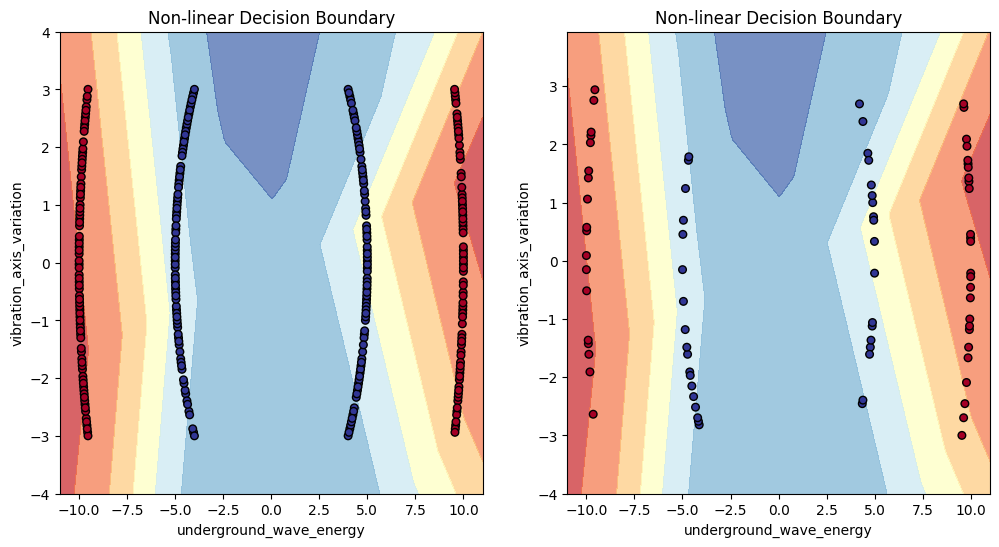

In [187]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_nonlinear_decision_boundary(model_1, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_nonlinear_decision_boundary(model_1, X_test, y_test)

plt.show()
# ChatGPT'ye yazdırılmıştır. Atıl Samancıoğlu'nun github'ından alnmıştır.